In [1]:
import librosa
import librosa.display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path

In [2]:
PROJECT_ROOT = Path("..")

metadata = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "metadata" /
    "metadata.csv"
)

sample = metadata.iloc[0]

audio_path = Path(sample["filepath"])

audio, sr = librosa.load(audio_path, sr=None)

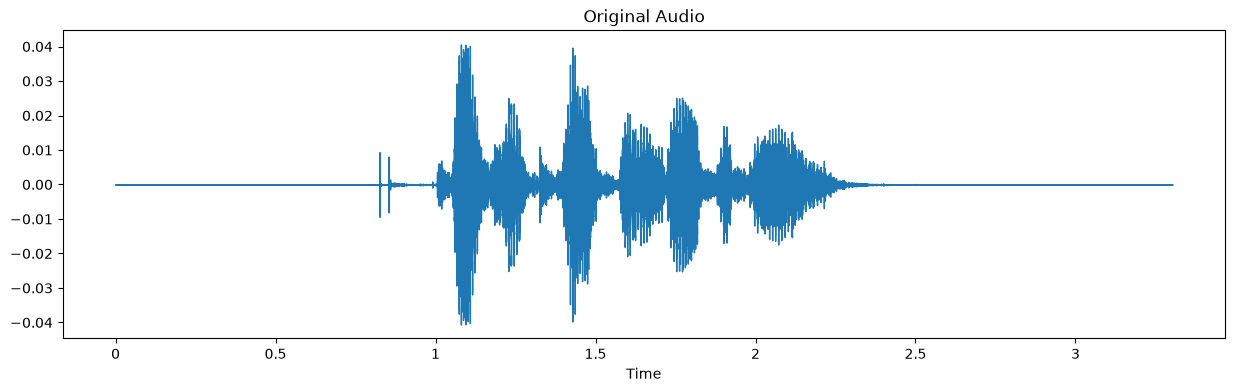

In [3]:
plt.figure(figsize=(15,4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Original Audio")

plt.show()

In [4]:
trimmed_audio, index = librosa.effects.trim(audio)

In [5]:
print(index)

[ 37376 139264]


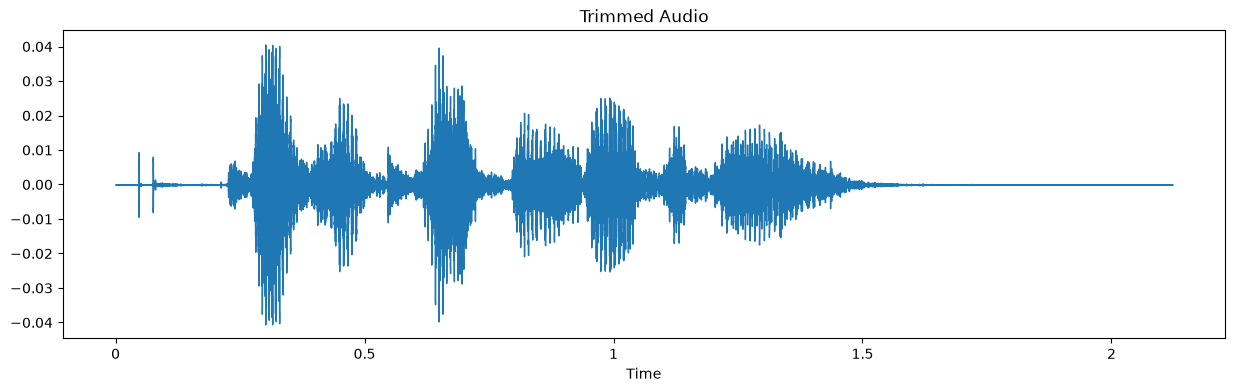

In [6]:
plt.figure(figsize=(15,4))

librosa.display.waveshow(trimmed_audio, sr=sr)

plt.title("Trimmed Audio")

plt.show()

In [7]:
original_duration = len(audio)/sr

trimmed_duration = len(trimmed_audio)/sr

print(original_duration)

print(trimmed_duration)

3.3032916666666665
2.1226666666666665


In [8]:
TARGET_SR = 16000

resampled_audio = librosa.resample(
    trimmed_audio,
    orig_sr=sr,
    target_sr=TARGET_SR
)

In [9]:
print(len(trimmed_audio))

print(len(resampled_audio))

101888
33963


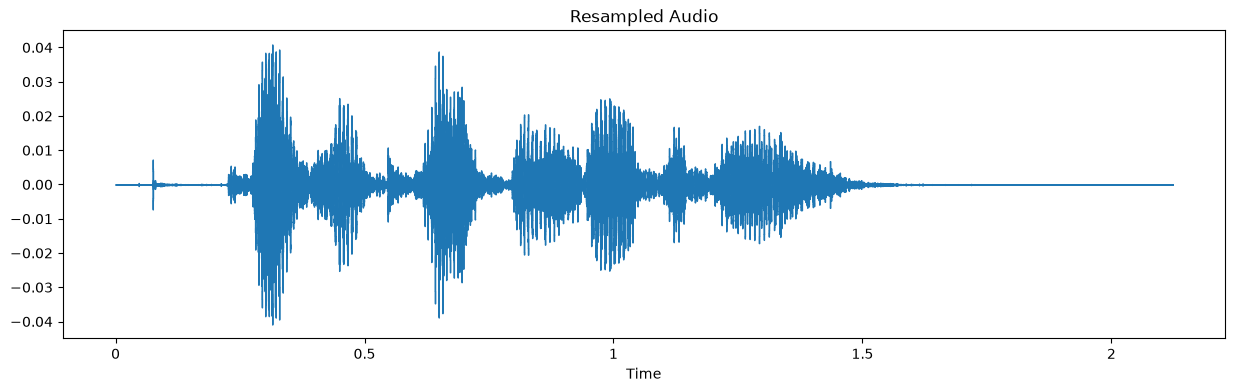

In [10]:
plt.figure(figsize=(15,4))

librosa.display.waveshow(
    resampled_audio,
    sr=TARGET_SR
)

plt.title("Resampled Audio")

plt.show()

In [11]:
normalized_audio = librosa.util.normalize(
    resampled_audio
)

In [12]:
print(normalized_audio.max())

print(normalized_audio.min())

1.0
-0.93636364


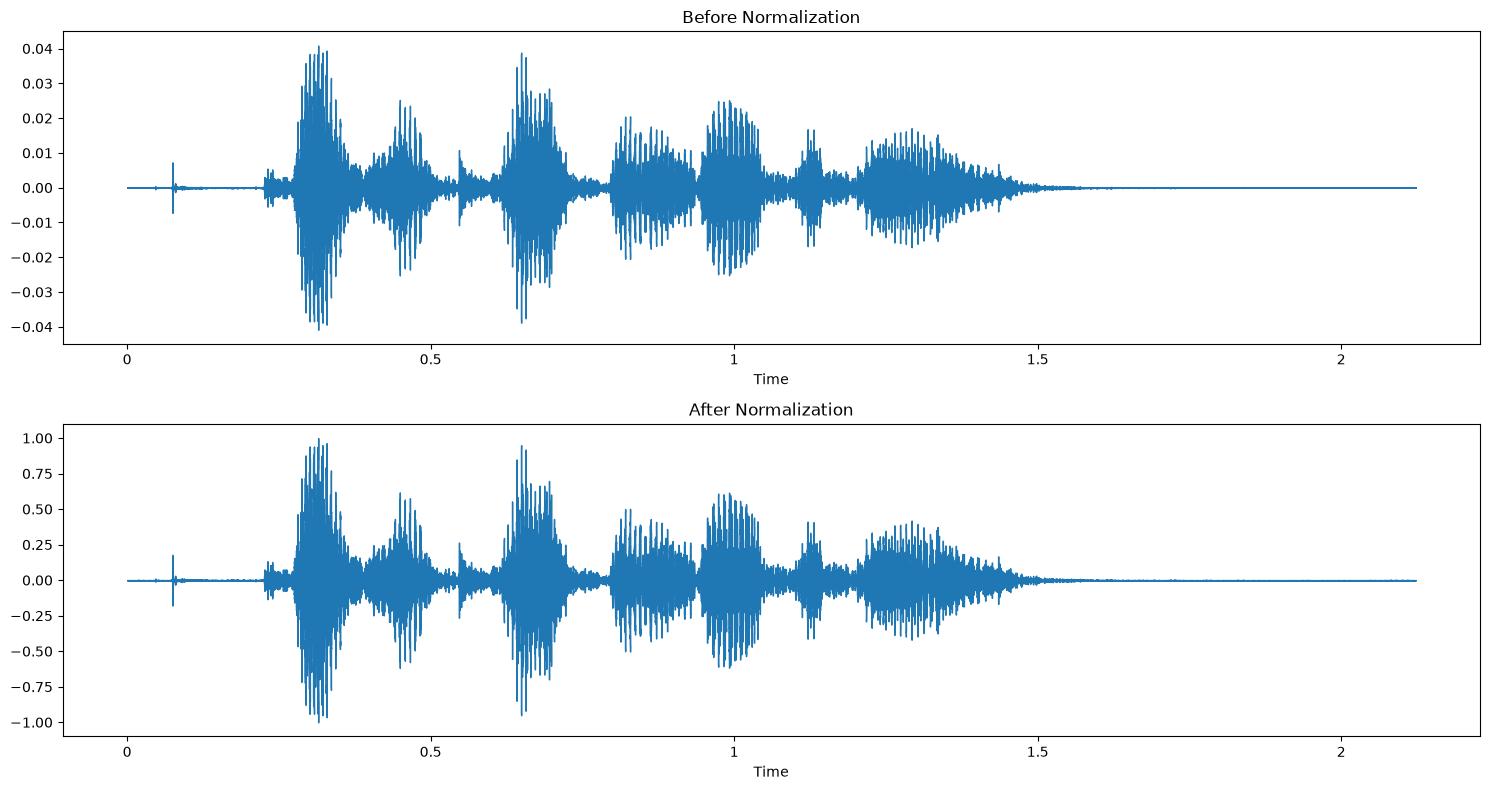

In [13]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(15,8)
)

librosa.display.waveshow(
    resampled_audio,
    sr=TARGET_SR,
    ax=ax[0]
)

ax[0].set_title("Before Normalization")

librosa.display.waveshow(
    normalized_audio,
    sr=TARGET_SR,
    ax=ax[1]
)

ax[1].set_title("After Normalization")

plt.tight_layout()

plt.show()

In [14]:
TARGET_DURATION = 3

TARGET_LENGTH = TARGET_SR * TARGET_DURATION

In [15]:


print(TARGET_LENGTH)

48000


In [16]:
if len(normalized_audio) < TARGET_LENGTH:

    processed_audio = np.pad(
        normalized_audio,
        (0, TARGET_LENGTH-len(normalized_audio))
    )

else:

    processed_audio = normalized_audio[
        :TARGET_LENGTH
    ]

In [17]:
len(processed_audio)

48000